In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

np.random.seed(0)

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="HouseValue")

In [3]:
import os

os.makedirs("figs", exist_ok=True)

print("Figures folder created successfully.")

Figures folder created successfully.


In [4]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

Shape of X: (20640, 8)
Shape of y: (20640,)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows of X:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



First 5 values of y:


,HouseValue
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
print("DATASET INFORMATION")
print("-" * 50)
X.info()

print("\nFEATURE SUMMARY")
print("-" * 50)
display(X.describe())

print("\nTARGET SUMMARY")
print("-" * 50)
display(y.describe())

print("\nMISSING VALUES")
print("-" * 50)
print(X.isnull().sum())

print("\nMissing values in target:", y.isnull().sum())

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB

FEATURE SUMMARY
--------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000



TARGET SUMMARY
--------------------------------------------------


,HouseValue
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010



MISSING VALUES
--------------------------------------------------
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Missing values in target: 0


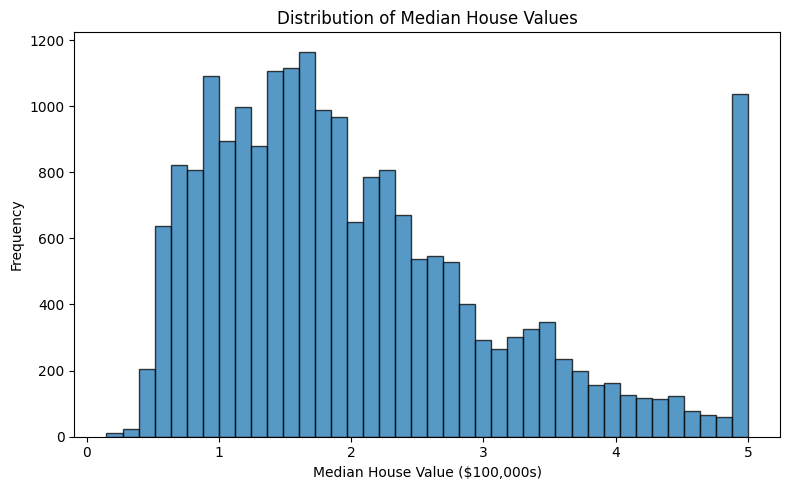

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=40, edgecolor="black", alpha=0.75)

plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Values")

plt.tight_layout()
plt.savefig("figs/01_house_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation
The distribution of median house values is right-skewed, with most districts concentrated at lower to moderate house values. A large spike appears at 5.0 (about $500,000), suggesting that the target variable is capped at an upper limit. This ceiling is important because it may affect how prediction models learn the relationship between features and house value.


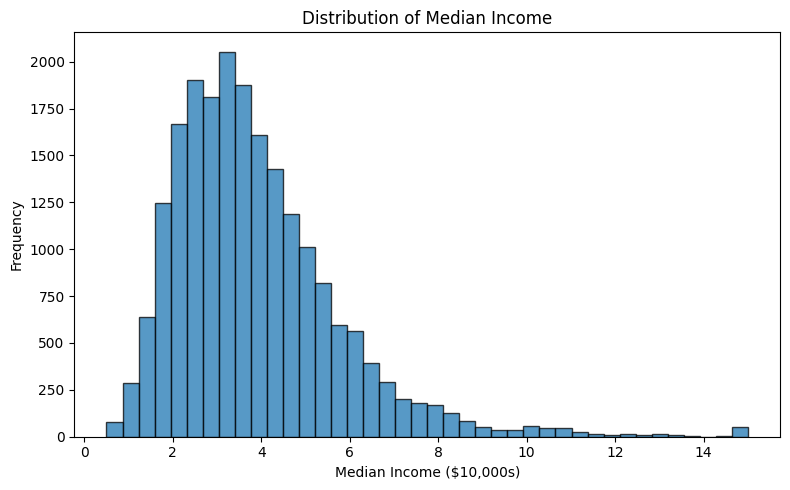

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(X["MedInc"], bins=40, edgecolor="black", alpha=0.75)

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Frequency")
plt.title("Distribution of Median Income")

plt.tight_layout()
plt.savefig("figs/02_median_income_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation
Median income is right-skewed. Most districts have median income values between roughly 2 and 5 ($10,000s), while relatively few districts have very high incomes. This indicates that high-income districts are comparatively rare in the dataset.

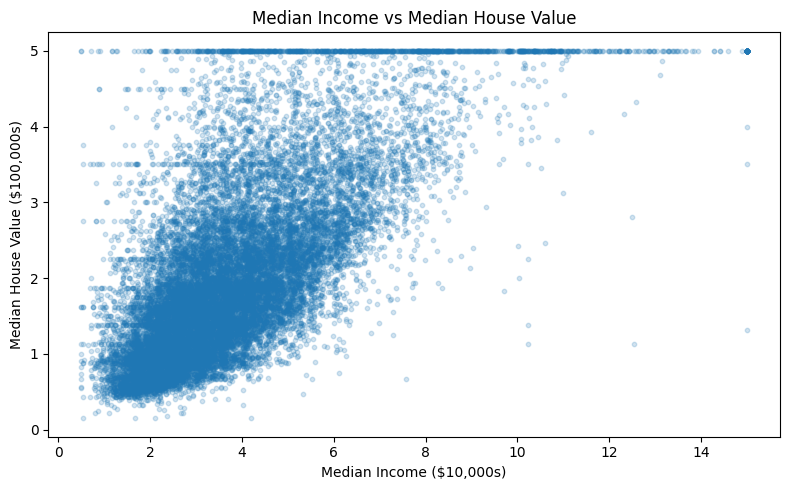

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(X["MedInc"], y, alpha=0.2, s=10)

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Median Income vs Median House Value")

plt.tight_layout()
plt.savefig("figs/03_income_vs_house_value.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Use Median Income as the single input feature
X_income = X[["MedInc"]]

# Global model
lr = LinearRegression()
lr.fit(X_income, y)

# Local model
knn_5 = KNeighborsRegressor(n_neighbors=5)
knn_5.fit(X_income, y)

print("Linear Regression fitted successfully.")
print("kNN (k=5) fitted successfully.")

print("\nLinear Regression coefficient:", lr.coef_[0])
print("Linear Regression intercept:", lr.intercept_)

Linear Regression fitted successfully.
kNN (k=5) fitted successfully.

Linear Regression coefficient: 0.41793849201896277
Linear Regression intercept: 0.45085576703267893


In [ ]:
# Create a smooth range of Median Income values
grid = np.linspace(
    X["MedInc"].min(),
    X["MedInc"].max(),
    300
).reshape(-1, 1)

# Predictions from both models
lr_pred = lr.predict(grid)
knn_5_pred = knn_5.predict(grid)

print("Grid shape:", grid.shape)
print("Linear Regression predictions:", lr_pred.shape)
print("kNN predictions:", knn_5_pred.shape)

Grid shape: (300, 1)
Linear Regression predictions: (300,)
kNN predictions: (300,)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [ ]:
grid = pd.DataFrame(
    np.linspace(
        X["MedInc"].min(),
        X["MedInc"].max(),
        300
    ),
    columns=["MedInc"]
)

# Predictions from both models
lr_pred = lr.predict(grid)
knn_5_pred = knn_5.predict(grid)

print("Grid shape:", grid.shape)
print("Linear Regression predictions:", lr_pred.shape)
print("kNN predictions:", knn_5_pred.shape)

Grid shape: (300, 1)
Linear Regression predictions: (300,)
kNN predictions: (300,)


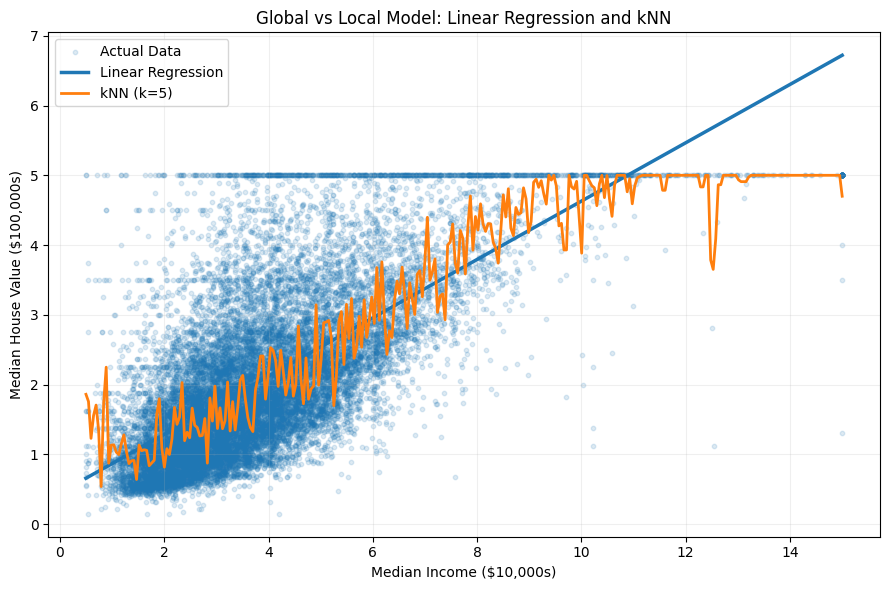

In [ ]:
plt.figure(figsize=(9, 6))

# Actual observations
plt.scatter(
    X["MedInc"],
    y,
    alpha=0.15,
    s=10,
    label="Actual Data"
)

# Global Linear Regression
plt.plot(
    grid["MedInc"],
    lr_pred,
    linewidth=2.5,
    label="Linear Regression"
)

# Local kNN model
plt.plot(
    grid["MedInc"],
    knn_5_pred,
    linewidth=2,
    label="kNN (k=5)"
)

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Global vs Local Model: Linear Regression and kNN")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/04_global_vs_local_k5.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Fit a smoother local model using more neighbors
knn_50 = KNeighborsRegressor(n_neighbors=50)
knn_50.fit(X_income, y)

# Predict on the same grid
knn_50_pred = knn_50.predict(grid)

print("kNN (k=50) fitted successfully.")
print("Prediction shape:", knn_50_pred.shape)

NameError: name 'X_income' is not defined

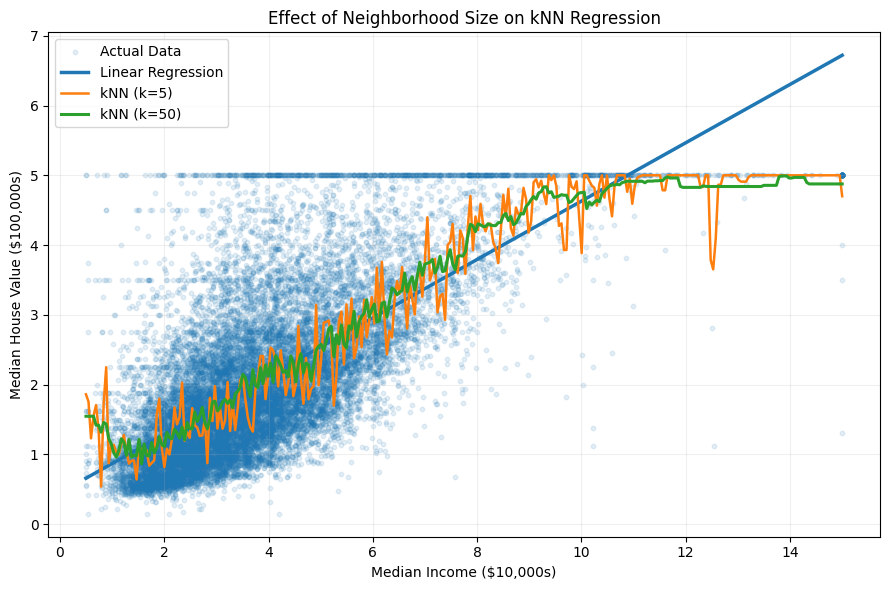

In [ ]:
plt.figure(figsize=(9, 6))

# Actual observations
plt.scatter(
    X["MedInc"],
    y,
    alpha=0.12,
    s=10,
    label="Actual Data"
)

# Global model
plt.plot(
    grid["MedInc"],
    lr_pred,
    linewidth=2.5,
    label="Linear Regression"
)

# Local models
plt.plot(
    grid["MedInc"],
    knn_5_pred,
    linewidth=1.8,
    label="kNN (k=5)"
)

plt.plot(
    grid["MedInc"],
    knn_50_pred,
    linewidth=2.2,
    label="kNN (k=50)"
)

plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.title("Effect of Neighborhood Size on kNN Regression")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/05_knn_k_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Reflection
Linear regression captures the overall positive relationship between median income and house value using a single global trend. In contrast, kNN adapts to local patterns in the data. With k=5, the prediction curve is highly sensitive to nearby observations and is quite irregular, while k=50 produces a smoother and more stable curve. This shows that smaller neighborhoods capture more local variation, whereas larger neighborhoods trade some local detail for smoother predictions.

In [ ]:
# Use the full response distribution
subset = y.copy()

# Compute mean and median
mean_val = subset.mean()
median_val = subset.median()

print("Mean House Value:", mean_val)
print("Median House Value:", median_val)

Mean House Value: 2.068558169089147
Median House Value: 1.797


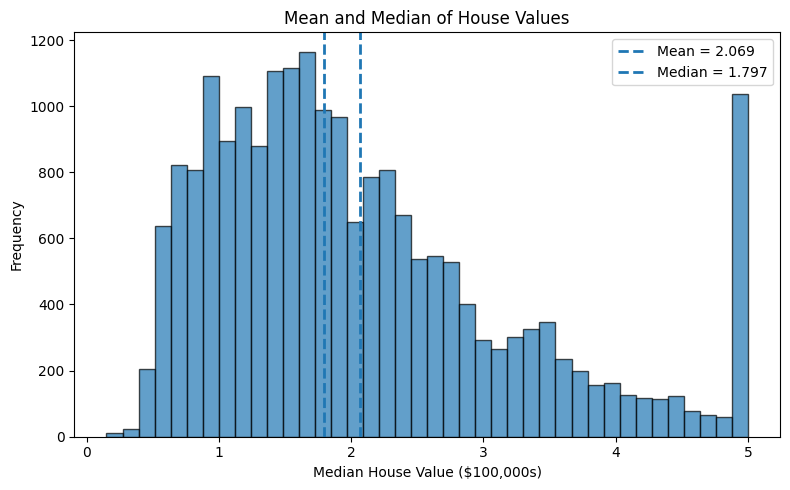

In [ ]:
plt.figure(figsize=(8, 5))

# Response distribution
plt.hist(subset, bins=40, edgecolor="black", alpha=0.7)

# Mean and median
plt.axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.3f}"
)

plt.axvline(
    median_val,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_val:.3f}"
)

plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Frequency")
plt.title("Mean and Median of House Values")

plt.legend()
plt.tight_layout()

plt.savefig(
    "figs/06_mean_median_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Candidate constant predictions
candidates = np.linspace(
    subset.min(),
    subset.max(),
    200
)

# Calculate risk for every candidate
squared_risk = [
    np.mean((subset - c) ** 2)
    for c in candidates
]

absolute_risk = [
    np.mean(np.abs(subset - c))
    for c in candidates
]

# Find the candidate that minimizes each loss
best_squared = candidates[np.argmin(squared_risk)]
best_absolute = candidates[np.argmin(absolute_risk)]

print("Mean:", mean_val)
print("Minimum squared-loss prediction:", best_squared)

print("\nMedian:", median_val)
print("Minimum absolute-loss prediction:", best_absolute)

Mean: 2.068558169089147
Minimum squared-loss prediction: 2.075374824120603

Median: 1.797
Minimum absolute-loss prediction: 1.8072832663316583


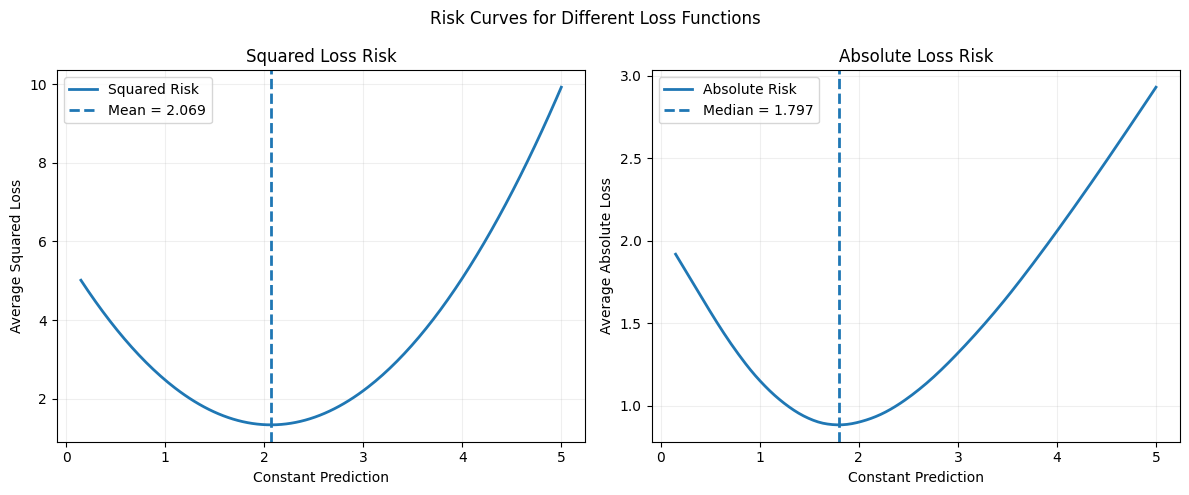

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Squared loss
axes[0].plot(
    candidates,
    squared_risk,
    linewidth=2,
    label="Squared Risk"
)

axes[0].axvline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.3f}"
)

axes[0].set_xlabel("Constant Prediction")
axes[0].set_ylabel("Average Squared Loss")
axes[0].set_title("Squared Loss Risk")
axes[0].legend()
axes[0].grid(alpha=0.2)


# Absolute loss
axes[1].plot(
    candidates,
    absolute_risk,
    linewidth=2,
    label="Absolute Risk"
)

axes[1].axvline(
    median_val,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_val:.3f}"
)

axes[1].set_xlabel("Constant Prediction")
axes[1].set_ylabel("Average Absolute Loss")
axes[1].set_title("Absolute Loss Risk")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.suptitle("Risk Curves for Different Loss Functions")
plt.tight_layout()

plt.savefig(
    "figs/07_loss_risk_curves.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Reflection
The squared-loss risk is minimized near the mean house value, while the absolute-loss risk is minimized near the median. This shows that the optimal prediction depends on how prediction error is measured. Squared loss penalizes large errors more strongly and therefore prefers the mean, whereas absolute loss is less sensitive to extreme values and prefers the median.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors

# Dimensions to investigate
dims = [1, 2, 4, 6, 8]

# Use a fixed train-test split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Dimensions to test:", dims)

Training samples: 16512
Testing samples: 4128
Dimensions to test: [1, 2, 4, 6, 8]


In [ ]:
results = []

for d in dims:
    # Select first d features
    X_train_d = X_train.iloc[:, :d]
    X_test_d = X_test.iloc[:, :d]

    # Standardize features
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_d)
    X_test_scaled = scaler.transform(X_test_d)

    # Average nearest-neighbor distance
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X_train_scaled)

    distances, indices = nn.kneighbors(X_train_scaled)

    # First neighbor is the point itself, so use second neighbor
    avg_nn_distance = distances[:, 1].mean()

    # Linear Regression
    lr_d = LinearRegression()
    lr_d.fit(X_train_scaled, y_train)

    lr_predictions = lr_d.predict(X_test_scaled)
    lr_mse = mean_squared_error(y_test, lr_predictions)

    # kNN Regression
    knn_d = KNeighborsRegressor(n_neighbors=5)
    knn_d.fit(X_train_scaled, y_train)

    knn_predictions = knn_d.predict(X_test_scaled)
    knn_mse = mean_squared_error(y_test, knn_predictions)

    # Store results
    results.append({
        "Dimension": d,
        "Avg_NN_Distance": avg_nn_distance,
        "Linear_MSE": lr_mse,
        "kNN_MSE": knn_mse
    })

print("Dimensionality experiment completed.")

Dimensionality experiment completed.


In [ ]:
# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display results
display(results_df.round(4))

,Dimension,Avg_NN_Distance,Linear_MSE,kNN_MSE
0,1,0.0002,0.7091,0.8267
1,2,0.0078,0.6630,0.7131
2,4,0.1199,0.6436,0.5902
3,6,0.2258,0.6422,0.5628
4,8,0.3435,0.5559,0.4324


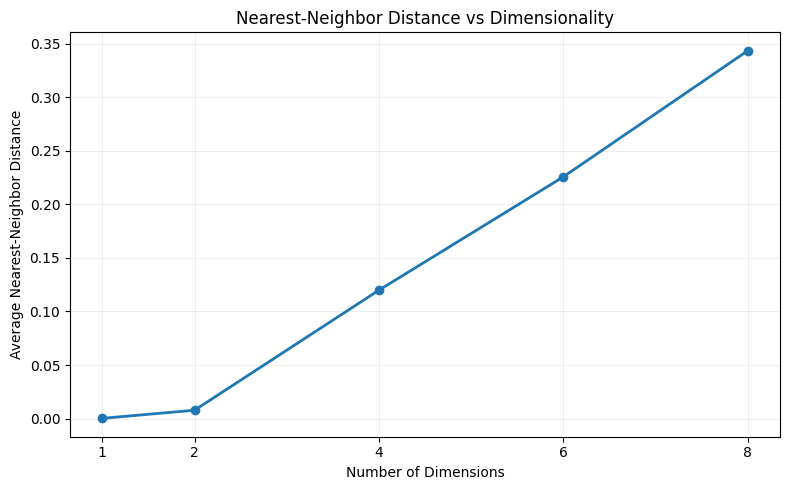

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Dimension"],
    results_df["Avg_NN_Distance"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Average Nearest-Neighbor Distance")
plt.title("Nearest-Neighbor Distance vs Dimensionality")

plt.xticks(dims)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/08_nn_distance_vs_dimension.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

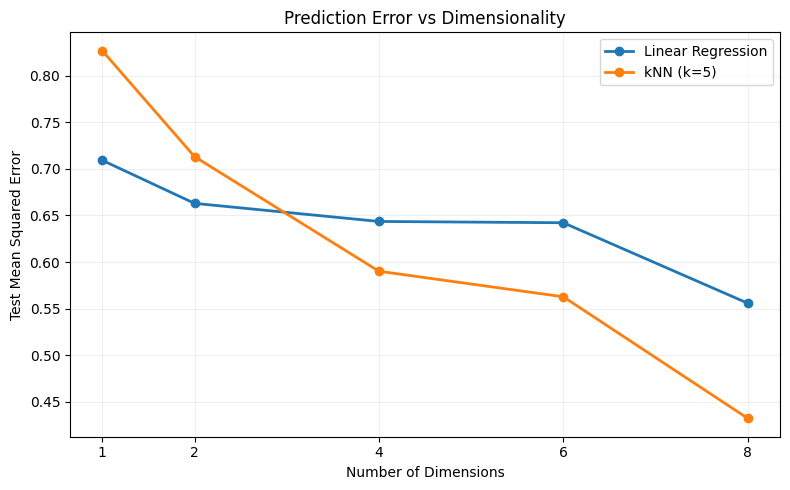

In [ ]:
plt.figure(figsize=(8, 5))

# Linear Regression error
plt.plot(
    results_df["Dimension"],
    results_df["Linear_MSE"],
    marker="o",
    linewidth=2,
    label="Linear Regression"
)

# kNN error
plt.plot(
    results_df["Dimension"],
    results_df["kNN_MSE"],
    marker="o",
    linewidth=2,
    label="kNN (k=5)"
)

plt.xlabel("Number of Dimensions")
plt.ylabel("Test Mean Squared Error")
plt.title("Prediction Error vs Dimensionality")

plt.xticks(dims)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/09_model_error_vs_dimension.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Reflection
As dimensionality increases, the average nearest-neighbor distance rises substantially, showing that neighborhoods become less local in higher-dimensional spaces. However, kNN test error decreases in this experiment because the added dimensions are real housing features that provide useful predictive information. Thus, increasing dimensionality creates a geometric disadvantage for local methods, but informative additional features can still improve prediction enough to offset this effect. This highlights that the curse of dimensionality concerns the geometry of high-dimensional spaces, not a guarantee that model error must always increase.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Standardize all 8 features
scaler_structured = StandardScaler()

X_train_scaled_full = scaler_structured.fit_transform(X_train)
X_test_scaled_full = scaler_structured.transform(X_test)

# Ordinary Least Squares
ols_model = LinearRegression()
ols_model.fit(X_train_scaled_full, y_train)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_full, y_train)

# Lasso Regression
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_scaled_full, y_train)

print("OLS, Ridge, and Lasso fitted successfully.")

OLS, Ridge, and Lasso fitted successfully.


In [ ]:
# Predictions
ols_pred = ols_model.predict(X_test_scaled_full)
ridge_pred = ridge_model.predict(X_test_scaled_full)
lasso_pred = lasso_model.predict(X_test_scaled_full)

# Test MSE
ols_mse = mean_squared_error(y_test, ols_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("OLS Test MSE:", ols_mse)
print("Ridge Test MSE:", ridge_mse)
print("Lasso Test MSE:", lasso_mse)

# Coefficient comparison
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "OLS": ols_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

display(coef_df.round(4))

OLS Test MSE: 0.5558915986952442
Ridge Test MSE: 0.5558548589435968
Lasso Test MSE: 0.5482548967938964


,Feature,OLS,Ridge,Lasso
0,MedInc,0.8544,0.8543,0.8010
1,HouseAge,0.1225,0.1226,0.1271
2,AveRooms,-0.2944,-0.2942,-0.1628
3,AveBedrms,0.3393,0.3390,0.2062
4,Population,-0.0023,-0.0023,-0.0000
5,AveOccup,-0.0408,-0.0408,-0.0306
6,Latitude,-0.8969,-0.8962,-0.7901
7,Longitude,-0.8698,-0.8691,-0.7557


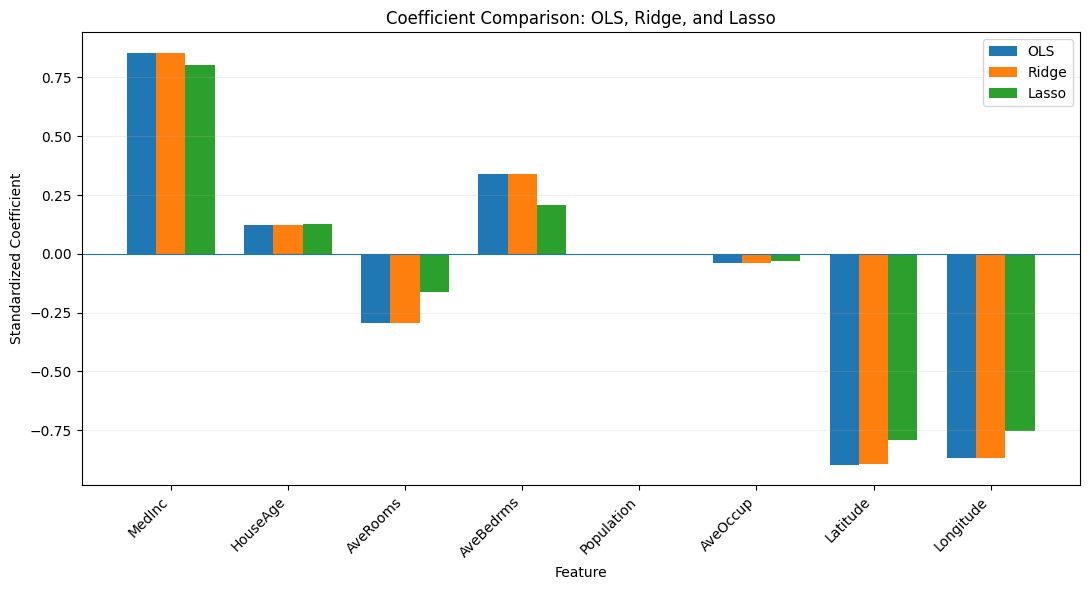

In [ ]:
x = np.arange(len(coef_df["Feature"]))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    coef_df["OLS"],
    width,
    label="OLS"
)

plt.bar(
    x,
    coef_df["Ridge"],
    width,
    label="Ridge"
)

plt.bar(
    x + width,
    coef_df["Lasso"],
    width,
    label="Lasso"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Feature")
plt.ylabel("Standardized Coefficient")
plt.title("Coefficient Comparison: OLS, Ridge, and Lasso")

plt.xticks(
    x,
    coef_df["Feature"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/10_regularization_coefficients.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Different regularization strengths
alphas = np.logspace(-4, 2, 15)

ridge_cv_mse = []
lasso_cv_mse = []

for alpha in alphas:

    # Ridge
    ridge = Ridge(alpha=alpha)

    ridge_scores = cross_val_score(
        ridge,
        X_train_scaled_full,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    ridge_cv_mse.append(-ridge_scores.mean())

    # Lasso
    lasso = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso_scores = cross_val_score(
        lasso,
        X_train_scaled_full,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    lasso_cv_mse.append(-lasso_scores.mean())


# Best alpha for each model
best_ridge_alpha = alphas[np.argmin(ridge_cv_mse)]
best_lasso_alpha = alphas[np.argmin(lasso_cv_mse)]

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Ridge CV MSE:", min(ridge_cv_mse))

print("\nBest Lasso alpha:", best_lasso_alpha)
print("Best Lasso CV MSE:", min(lasso_cv_mse))

Best Ridge alpha: 0.1
Best Ridge CV MSE: 0.5192651994657134

Best Lasso alpha: 0.0007196856730011522
Best Lasso CV MSE: 0.5192391063000983


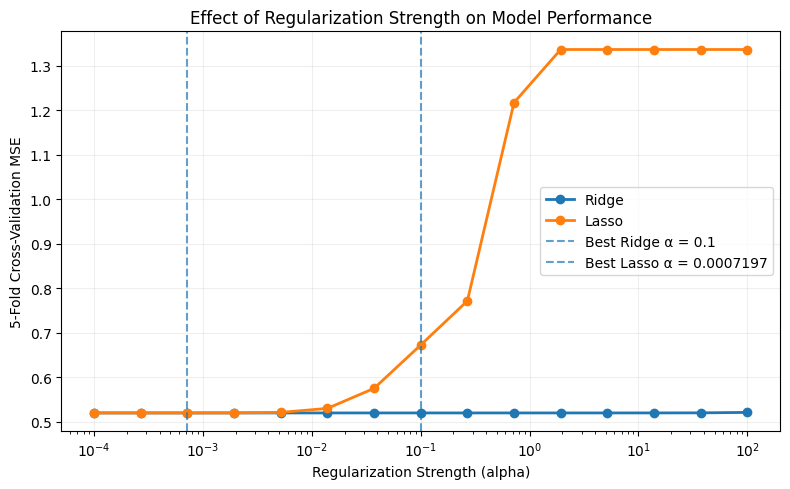

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    ridge_cv_mse,
    marker="o",
    linewidth=2,
    label="Ridge"
)

plt.plot(
    alphas,
    lasso_cv_mse,
    marker="o",
    linewidth=2,
    label="Lasso"
)

# Log scale because alpha spans several orders of magnitude
plt.xscale("log")

# Mark best alpha values
plt.axvline(
    best_ridge_alpha,
    linestyle="--",
    alpha=0.7,
    label=f"Best Ridge α = {best_ridge_alpha:.4g}"
)

plt.axvline(
    best_lasso_alpha,
    linestyle="--",
    alpha=0.7,
    label=f"Best Lasso α = {best_lasso_alpha:.4g}"
)

plt.xlabel("Regularization Strength (alpha)")
plt.ylabel("5-Fold Cross-Validation MSE")
plt.title("Effect of Regularization Strength on Model Performance")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "figs/11_regularization_cv.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Reflection
Ridge and Lasso introduce structure by penalizing large coefficients. Ridge produced coefficients very similar to ordinary least squares and remained stable across a wide range of regularization strengths. Lasso shrank several coefficients more strongly and reduced the Population coefficient to approximately zero, demonstrating its ability to perform feature selection. Cross-validation showed that relatively weak regularization performed best, while excessive Lasso regularization increased prediction error substantially due to underfitting.

In [ ]:
import os

figure_files = sorted(os.listdir("figs"))

print("Total figures saved:", len(figure_files))
print("\nSaved figures:")

for i, filename in enumerate(figure_files, 1):
    print(f"{i}. {filename}")

Total figures saved: 11

Saved figures:
1. 01_house_value_distribution.png
2. 02_median_income_distribution.png
3. 03_income_vs_house_value.png
4. 04_global_vs_local_k5.png
5. 05_knn_k_comparison.png
6. 06_mean_median_distribution.png
7. 07_loss_risk_curves.png
8. 08_nn_distance_vs_dimension.png
9. 09_model_error_vs_dimension.png
10. 10_regularization_coefficients.png
11. 11_regularization_cv.png


In [ ]:
import shutil

shutil.make_archive(
    "figs",
    "zip",
    "figs"
)

print("figs.zip created successfully.")

figs.zip created successfully.


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Same train-test split used earlier in the notebook
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize all 8 features
final_scaler = StandardScaler()

X_train_final = final_scaler.fit_transform(X_train)
X_test_final = final_scaler.transform(X_test)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

Training shape: (16512, 8)
Testing shape: (4128, 8)


In [10]:
# Final Linear Regression model
final_linear = LinearRegression()
final_linear.fit(X_train_final, y_train)

# Final kNN model
final_knn = KNeighborsRegressor(n_neighbors=5)
final_knn.fit(X_train_final, y_train)

print("Linear Regression and kNN models trained successfully.")

Linear Regression and kNN models trained successfully.


In [11]:
# Generate predictions
linear_pred = final_linear.predict(X_test_final)
knn_pred = final_knn.predict(X_test_final)

# Linear Regression metrics
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

# kNN metrics
knn_mse = mean_squared_error(y_test, knn_pred)
knn_rmse = np.sqrt(knn_mse)
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

# Display results
print("LINEAR REGRESSION")
print(f"MSE  : {linear_mse:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")
print(f"R²   : {linear_r2:.4f}")

print("\nkNN (k=5)")
print(f"MSE  : {knn_mse:.4f}")
print(f"RMSE : {knn_rmse:.4f}")
print(f"MAE  : {knn_mae:.4f}")
print(f"R²   : {knn_r2:.4f}")

LINEAR REGRESSION
MSE  : 0.5559
RMSE : 0.7456
MAE  : 0.5332
R²   : 0.5758

kNN (k=5)
MSE  : 0.4324
RMSE : 0.6576
MAE  : 0.4462
R²   : 0.6700


Model trained on KNN is better


In [12]:
# Final model performance comparison

final_results = pd.DataFrame({
    "Model": ["Linear Regression", "kNN (k=5)"],
    "MSE": [linear_mse, knn_mse],
    "RMSE": [linear_rmse, knn_rmse],
    "MAE": [linear_mae, knn_mae],
    "R² Score": [linear_r2, knn_r2]
})

print("FINAL MODEL PERFORMANCE")
print("-" * 60)

display(final_results.round(4))

# Select model with lowest test MSE
best_index = final_results["MSE"].idxmin()
best_model = final_results.loc[best_index]

print("\nBEST MODEL:", best_model["Model"])
print(f"MSE  : {best_model['MSE']:.4f}")
print(f"RMSE : {best_model['RMSE']:.4f}")
print(f"MAE  : {best_model['MAE']:.4f}")
print(f"R²   : {best_model['R² Score']:.4f}")

FINAL MODEL PERFORMANCE
------------------------------------------------------------


,Model,MSE,RMSE,MAE,R² Score
0,Linear Regression,0.5559,0.7456,0.5332,0.5758
1,kNN (k=5),0.4324,0.6576,0.4462,0.6700



BEST MODEL: kNN (k=5)
MSE  : 0.4324
RMSE : 0.6576
MAE  : 0.4462
R²   : 0.6700
